# Analisis Model Explainability - Skforecast 0.15.1

## 1. Analisa prediksi tentang apa?

Analisis prediksi dalam panduan tersebut adalah mengenai prakiraan (forecasting) permintaan listrik harian (electricity demand) di Victoria, Australia menggunakan dataset vic_electricity.
    
Tujuan utamanya adalah memprediksi total konsumsi energi listrik harian berdasarkan pola konsumsi di masa lalu serta pengaruh dari faktor eksternal, yaitu suhu udara.

## 2. Bagaimana bentuk data trainingnya (apa saja input dan         outputnya)?

Sebelum dimasukkan ke dalam model, data mentah yang berfrekuensi per 30 menit diakumulasikan (resample) menjadi frekuensi harian ('D'). Bentuk matriks training ($X$ dan $y$) yang dikonstruasikan oleh Skforecast terdiri dari:
    
- Input (Fitur / Predictors / $X_{train}$):
    - Lags (lag_1 sampai lag_7): Nilai total permintaan listrik dari 1 hingga 7 hari sebelumnya (1 minggu ke belakang).
    - Exogenous Variable (Temperature): Nilai rata-rata suhu udara harian pada hari yang diprediksi. Suhu digunakan sebagai input luar (eksogen) karena memiliki korelasi kuat dengan penggunaan alat pemanas atau pendingin ruangan yang memengaruhi beban listrik.
- Output (Target / $y_{train}$):
    - Demand: Jumlah total permintaan listrik pada hari yang bersangkutan (nilai aktual yang ingin ditebak oleh model).

## 3. Apa itu lag?

Dalam analisis deret waktu (time series forecasting), lag (keterlambatan/selisih waktu) adalah nilai historis dari variabel target pada titik waktu sebelumnya.Sebagai contoh, jika kita ingin memprediksi permintaan listrik untuk hari ini (Hari $t$):

- lag_1: Nilai permintaan listrik 1 hari yang lalu (kemarin / $t-1$).
- lag_2: Nilai permintaan listrik 2 hari yang lalu ($t-2$).
- lag_7: Nilai permintaan listrik 7 hari yang lalu (seminggu yang lalu / $t-7$).

Lag digunakan sebagai fitur input agar algoritma machine learning berbasis regresi (seperti LightGBM) dapat mempelajari pola tren dan musiman (seasonality) dari data masa lalu demi memproyeksikan nilai di masa depan.

## 4. Jelaskan proses analysis yang dilakukan dari kasus diatas

Proses analisis yang berjalan dalam panduan tersebut terbagi menjadi beberapa tahapan end-to-end berikut ini:

1. Persiapan Library dan Data (Libraries and Data Loading):
    - Mengimpor library utama seperti pandas, skforecast (ForecasterRecursive), lightgbm (LGBMRegressor), shap, dan fungsi visualisasi dari sklearn.
    - Mengunduh dataset vic_electricity.

2. Pra-pemrosesan Data (Data Preprocessing & Resampling):
    - Mengubah data dari interval 30 menitan menjadi harian. Kolom Demand dijumlahkan (sum) untuk mendapatkan total harian, sedangkan kolom Temperature dirata-ratakan (mean).

3. Pembagian Data Pembelajaran (Train-Test Split):
    - Data dipotong menjadi data training (data_train) dari awal data hingga tanggal 21 Desember 2014, dan sisanya digunakan sebagai data pengujian (data_test).

4. Inisialisasi dan Pelatihan Model (Create and Train Forecaster):
    - Membuat objek ForecasterRecursive dengan menyematkan regressor LGBMRegressor di dalamnya dan menentukan jumlah lags = 7.
    - Melatih model menggunakan fungsi .fit() dengan memasukkan target $y$ (Demand) dan variabel eksogen (Temperature).

5. Analisis Transparansi Model (Model Explainability):
    Setelah model selesai dilatih, panduan ini melakukan eksperimen menggunakan 4 teknik interpretabilitas untuk memahami bagaimana model mengambil keputusan (membongkar sifat black-box):
    
    - Model-Specific Feature Importance: Mengambil bobot kepentingan fitur bawaan dari LightGBM menggunakan forecaster.get_feature_importances(). Hasilnya menunjukkan bahwa fitur Temperature dan lag_1 (permintaan kemarin) menjadi faktor paling dominan dalam pembentukan pohon keputusan.
    - SHAP Values (Shapley Additive exPlanations): Menggunakan library shap untuk menghitung kontribusi tiap fitur secara aditif. Hal ini membantu memvisualisasikan dampak positif/negatif dari nilai fitur tertentu terhadap hasil prediksi (baik secara keseluruhan melalui Summary Plot maupun secara spesifik per observasi).
    - Permutation Feature Importance: Melakukan pengacakan nilai pada satu fitur tertentu, lalu mengukur seberapa jatuh performa akurasi model. Fitur yang menyebabkan performa drop paling besar ketika diacak mengindikasikan bahwa model sangat bergantung pada fitur tersebut (dalam kasus ini lag_1 memiliki pengaruh permutation tertinggi).
    - Partial Dependence Plots (PDP): Membuat grafik untuk melihat hubungan marginal antara satu atau dua fitur (misal: naik turunnya suhu udara) terhadap prediksi permintaan listrik dengan mengasumsikan fitur-fitur lainnya konstan.

## Reproduct ulang Kode Program

1. Instalasi Library

In [16]:
!pip install skforecast==0.15.1 shap

Penjelasan: Perintah ini mengunduh dan memasang skforecast versi 0.15.1, lightgbm sebagai algoritma regresi, dan shap untuk keperluan visualisasi kontribusi fitur.

2. Import Library

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shap
from sklearn.inspection import permutation_importance
from sklearn.inspection import PartialDependenceDisplay
from lightgbm import LGBMRegressor
from skforecast.datasets import fetch_dataset
from skforecast.recursive import ForecasterRecursive

# Mengaktifkan visualisasi javascript untuk SHAP di notebook
shap.initjs()

Penjelasan: Kita mengimpor ForecasterRecursive dari Skforecast untuk menangani prediksi multi-step secara rekursif, LGBMRegressor sebagai mesin kecerdasan buatan, serta fungsi inspeksi dari sklearn untuk menghitung tingkat kepentingan fitur (permutation & partial dependence).

3. Pemuatan dan penyiapan Dataset

In [18]:
# 1. Ambil dataset listrik dari Victoria, Australia
data = fetch_dataset(name="vic_electricity")

# 2. Resample (mengubah frekuensi) menjadi Harian ('D')
# Total permintaan listrik dijumlahkan, rata-rata suhu dihitung per hari
data = data.resample('D').agg({'Demand': 'sum', 'Temperature': 'mean'})

# 3. Memisahkan data menjadi Training dan Testing
data_train = data.loc[: '2014-12-21']
data_test = data.loc['2014-12-22':]

# Tampilkan 3 data teratas dari data training
print(f"Jumlah data training: {len(data_train)} hari")
data_train.head(3)

vic_electricity
---------------
Half-hourly electricity demand for Victoria, Australia
O'Hara-Wild M, Hyndman R, Wang E, Godahewa R (2022).tsibbledata: Diverse
Datasets for 'tsibble'. https://tsibbledata.tidyverts.org/,
https://github.com/tidyverts/tsibbledata/.
https://tsibbledata.tidyverts.org/reference/vic_elec.html
Shape of the dataset: (52608, 4)
Jumlah data training: 1087 hari


,Demand,Temperature
Time,,
2011-12-31,82531.745918,21.047727
2012-01-01,227778.257304,26.578125
2012-01-02,275490.988882,31.751042


Penjelasan: Data mentah berfrekuensi 30 menit terlalu padat. Kita melakukan resampling ke skala harian ('D'). Kolom target adalah Demand (total energi harian) dan variabel pembantu (exogenous) adalah Temperature (rata-rata suhu harian). Data dilatih hingga tanggal 21 Desember 2014.

4. Membuat dan melatih Model Forecaster

In [19]:
# Inisialisasi objek peramal rekursif
forecaster = ForecasterRecursive(
    regressor = LGBMRegressor(random_state=123, verbose=-1),
    lags = 7  # Menggunakan data 7 hari ke belakang sebagai input otomatis
)

# Melatih model dengan menyertakan variabel eksogen (Suhu)
forecaster.fit(
    y = data_train['Demand'],
    exog = data_train['Temperature']
)

print("Model selesai dilatih!")

Model selesai dilatih!


Penjelasan: ForecasterRecursive akan otomatis mengubah deret waktu menjadi matriks regresi terbimbing (supervised learning). Model ini memprediksi Demand hari esok berdasarkan pola Demand 7 hari ke belakang (lags=7) digabungkan dengan informasi Temperature hari esok tersebut.

5. Teknik 1-Model Specific Feature Importance

In [20]:
# Mengambil tingkat kepentingan fitur bawaan dari regressor
feature_importances = forecaster.get_feature_importances()
feature_importances

,feature,importance
7,Temperature,570
0,lag_1,470
2,lag_3,387
1,lag_2,362
6,lag_7,325
5,lag_6,313
4,lag_5,298
3,lag_4,275


Penjelasan: Fungsi get_feature_importances() mengakses langsung bobot internal model LightGBM. Hasilnya akan memunculkan tabel nilai kepentingan untuk Temperature serta lag_1 sampai lag_7. Biasanya, Temperature dan lag_1 (nilai kemarin) memegang skor tertinggi.

6. Teknik 2-Global SHAP Values (Membuat Matriks Training & Explainer)

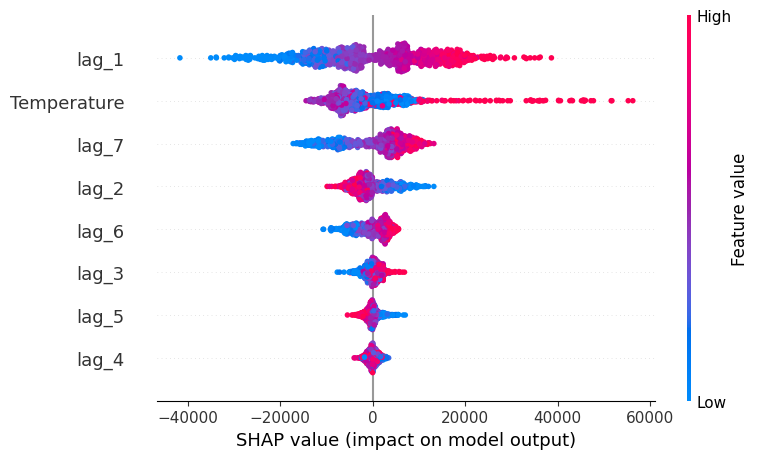

In [21]:
# 1. Ekstrak matriks X (input) dan y (output) yang dibuat oleh forecaster secara internal
X_train, y_train = forecaster.create_train_X_y(
    y = data_train['Demand'],
    exog = data_train['Temperature']
)

# 2. Membuat SHAP explainer khusus untuk model berbasis pohon (TreeExplainer)
explainer = shap.TreeExplainer(forecaster.regressor)
shap_values = explainer(X_train)

# 3. Membuat Summary Plot SHAP
plt.figure(figsize=(8, 5))
shap.summary_plot(shap_values, X_train)

Penjelasan: Kita harus mengekstrak matriks input buatan Skforecast terlebih dahulu menggunakan create_train_X_y. SHAP Summary Plot akan menampilkan sebaran titik kontribusi tiap fitur. Fitur di urutan paling atas adalah yang memberikan dampak perubahan paling besar terhadap prediksi beban listrik harian.

7. Teknik 3-Permutation Feature Importance

In [22]:
# Menghitung permutation importance pada data training
r = permutation_importance(
    estimator = forecaster.regressor,
    X = X_train,
    y = y_train,
    n_repeats = 3,      # Pengacakan diulang 3 kali untuk stabilitas
    max_samples = 0.5,  # Menggunakan 50% sampel data demi kecepatan
    random_state = 123
)

# Menyusun hasil pengacakan ke dalam DataFrame
importances = pd.DataFrame({
    'feature': X_train.columns,
    'mean_importance': r.importances_mean,
    'std_importance': r.importances_std
}).sort_values('mean_importance', ascending=False)

importances

,feature,mean_importance,std_importance
0,lag_1,0.617276,0.014583
7,Temperature,0.411240,0.014405
6,lag_7,0.196190,0.001865
1,lag_2,0.122398,0.007803
5,lag_6,0.083912,0.003637
2,lag_3,0.041294,0.002019
4,lag_5,0.030787,0.001079
3,lag_4,0.024816,0.001021


Penjelasan: Jika suatu fitur diacak-acak nilainya (permutation) dan performa eror model meningkat tajam (skor mean_importance besar), artinya model tersebut sangat bergantung pada fitur tersebut. Dari pengujian ini, kita dapat memvalidasi apakah lag_1 atau Temperature benar-benar pilar utama prediksi.

8. Teknik 4-Partial Dependence Plots

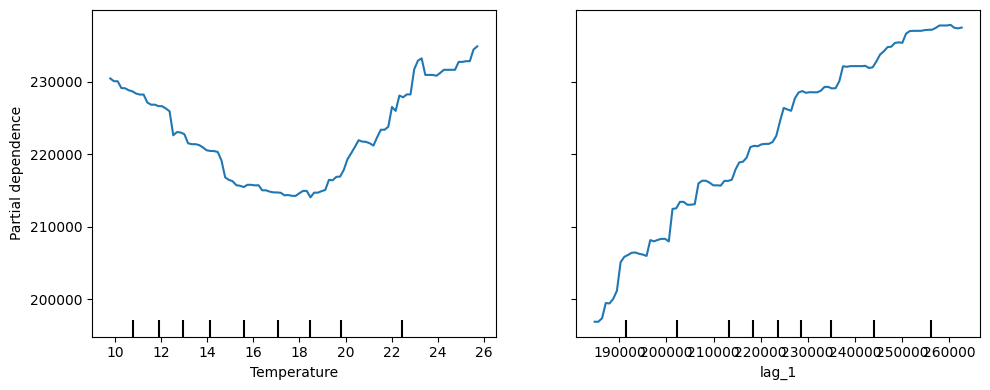

In [23]:
# Membuat grafik Partial Dependence untuk fitur 'Temperature' dan 'lag_1'
fig, ax = plt.subplots(figsize=(10, 4))
PartialDependenceDisplay.from_estimator(
    estimator = forecaster.regressor,
    X = X_train,
    features = ['Temperature', 'lag_1'], # Fitur yang ingin diisolasi trennya
    kind = 'average',
    ax = ax
)
plt.tight_layout()
plt.show()

Penjelasan: PDP mengisolasi efek dari satu fitur tertentu dengan mengasumsikan nilai fitur lainnya konstan/rata-rata. Grafik ini sangat berguna untuk melihat sifat hubungan non-linear, misalnya: kita bisa melihat grafik permintaan listrik melengkung naik tajam saat Temperature sangat dingin (butuh pemanas) atau saat sangat panas (butuh pendingin ruangan/AC).

## Kesimpulan

Kesimpulan Analisis Model Explainability
Berdasarkan seluruh rangkaian proses reproduksi kode dan analisis yang telah kita lakukan, berikut adalah kesimpulan utama yang dapat ditarik:

- Pola Konsumsi Energi Sangat Dependen pada Waktu Lampau (Momentum): Fitur lag_1 (permintaan listrik kemarin) dan lag_7 (permintaan listrik seminggu yang lalu) terbukti menjadi pilar utama prediksi model. Ini menunjukkan bahwa konsumsi listrik harian memiliki pola musiman mingguan yang berulang (misalnya, pola hari Senin mirip dengan hari Senin berikutnya) serta ketergantungan jangka pendek yang kuat.

- Suhu Udara Adalah Pemicu Utama Fluktuasi Ekstrem: Meskipun lag mendominasi pola dasar harian, Temperature bertindak sebagai variabel pengubah (game changer). Melalui grafik Partial Dependence Plot (PDP), kita dapat menyimpulkan bahwa hubungan antara suhu dan permintaan listrik bersifat non-linear (membentuk kurva U). Permintaan listrik akan melonjak tajam dalam dua kondisi ekstrem: saat suhu sangat dingin (masyarakat menyalakan pemanas ruangan) dan saat suhu sangat panas (masyarakat menyalakan AC).

- Pentingnya Membongkar "Black Box" Model: Algoritma canggih seperti LightGBM sering kali akurat tetapi sulit dipahami secara intuitif. Dengan memanfaatkan kombinasi teknik Explainability (Feature Importance, SHAP, Permutation, dan PDP), kita tidak hanya mendapatkan model yang siap melakukan prediksi, tetapi juga mendapatkan wawasan bisnis (business insights) yang berharga dan transparan mengenai faktor apa saja yang menggerakkan naik-turunnya beban listrik di wilayah tersebut.

    Ringkasan Singkat: Model berhasil memprediksi beban listrik harian dengan memanfaatkan kombinasi cerdas antara tren kebiasaan masyarakat di masa lalu (Lags) dan anomali cuaca hari ini (Temperature).